프로젝트 1번의 A에 해당하는 코드입니다.

공동으로 사용되는 코드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_paths = [
    '/content/drive/My Drive/Colab Notebooks/D1_16.png',
    '/content/drive/My Drive/Colab Notebooks/D2_16.png',
    '/content/drive/My Drive/Colab Notebooks/D3_16.png',
    '/content/drive/My Drive/Colab Notebooks/D4_16.png',
    '/content/drive/My Drive/Colab Notebooks/D5_16.png'
]


Mounted at /content/drive


In [ ]:
#방법 1

# 16비트 중 상위 8비트 추출
def method_1(image_paths):

    for idx,image_path in enumerate(image_paths):                     #enumerate: 리스트 image_paths에서 각 항목을 순서대로 가져오면서, 각 항목에 대한 인덱스(번호)를 함께 반환

        image_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)    # 16-bit 이미지
        upper_8bit = (image_16bit >> 8).astype(np.uint8)              # 상위 8-bit 이미지
        lower_8bit = (image_16bit & 0xFF).astype(np.uint8)            # 하위 8-bit 이미지

        # 이미지 시각화
        plt.figure(figsize=(30, 10))

        plt.subplot(1, 3, 1)
        plt.title(f'original Image {idx+1}')
        plt.imshow(image_16bit, cmap='gray', vmin=0, vmax=65535)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title(f'Upper 8-bit Image {idx+1}')
        plt.imshow(upper_8bit, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title(f'Lower 8-bit Image {idx+1}')
        plt.imshow(lower_8bit, cmap='gray')
        plt.axis('off')

        plt.show()

# 이미지 처리 함수 호출
method_1(image_paths)

Output hidden; open in https://colab.research.google.com to view.

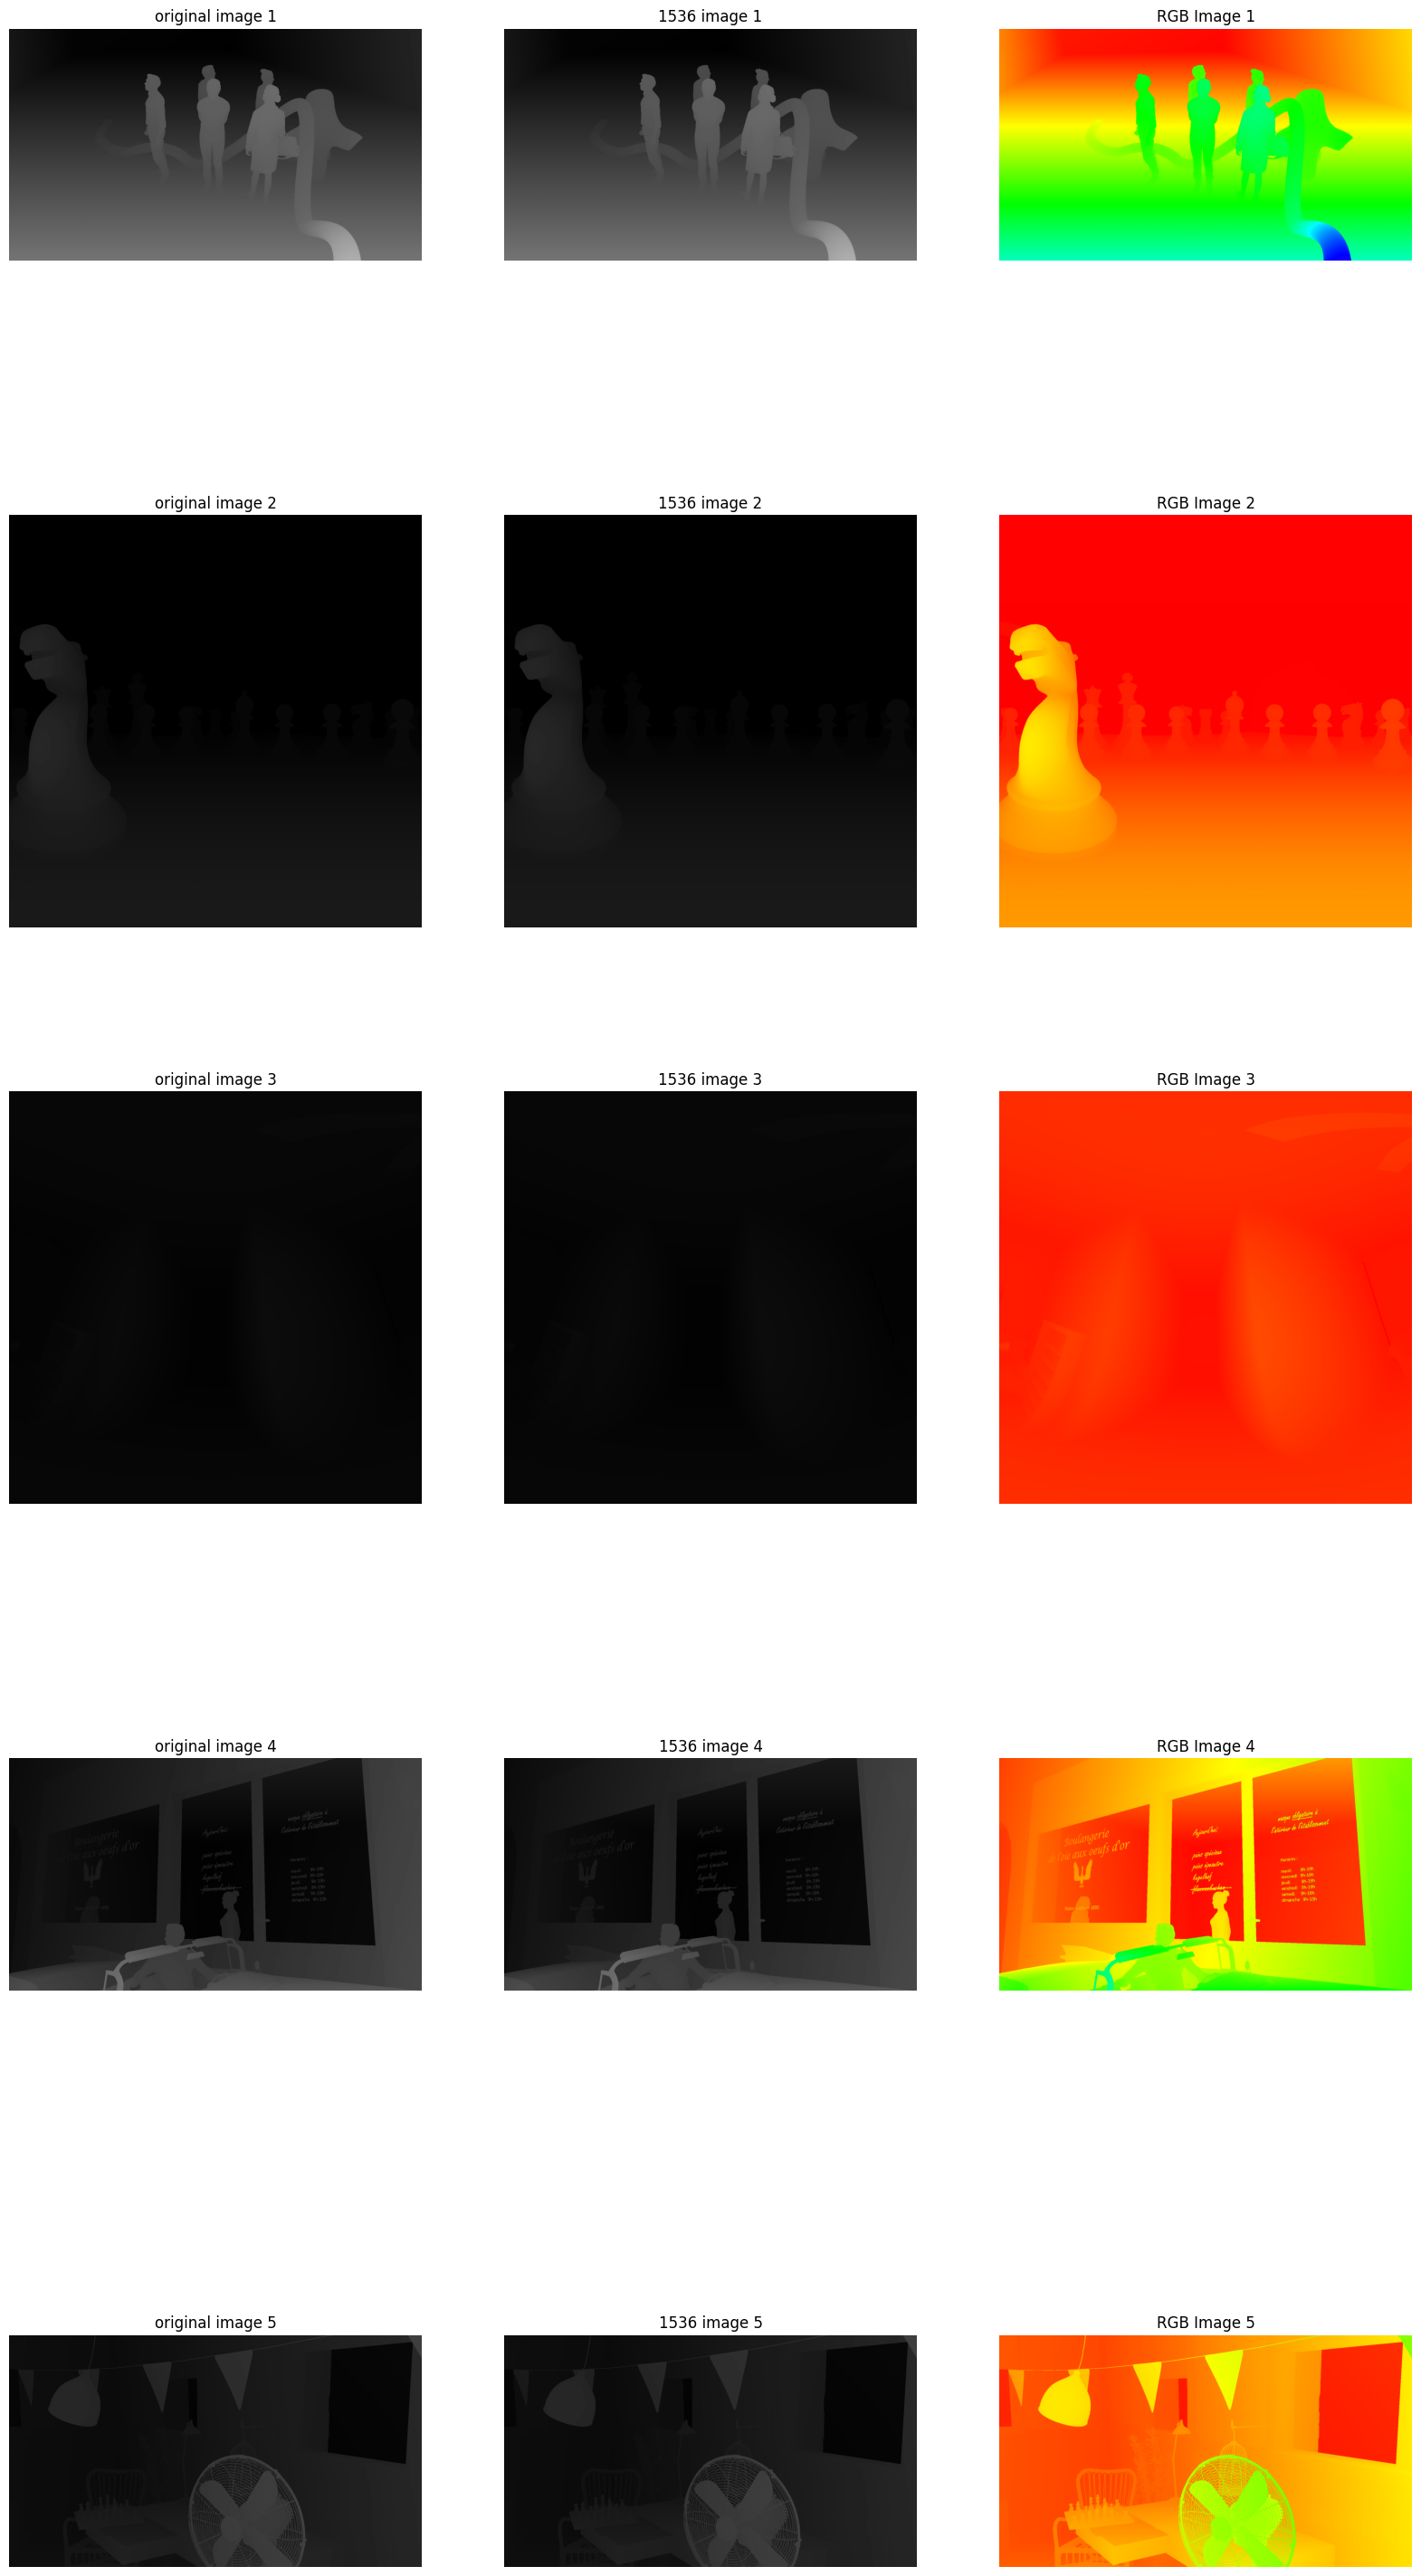

In [ ]:
#방법 2
results = []                                                            #이미지 저장 리스트

#16비트 이미지 RGB 매핑 함수
for image_path in image_paths:

    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)                #16비트 이미지
    normalized_image = (image / 65535 * 1535).astype(np.uint16)         #1536 정규화 이미지
    rgb_image = np.zeros((*normalized_image.shape, 3), dtype=np.uint8)  #RGB이미지 생성

#매핑 함수
    def map_to_rgb(value):
        if 0 <= value < 256:
            return (255, value, 0)                                      #(255, 0~255, 0)
        elif 256 <= value < 512:
            return (255 - (value - 256), 255, 0)                        #(255~0, 255, 0)
        elif 512 <= value < 768:
            return (0, 255, value - 512)                                #(0, 255, 0~255)
        elif 768 <= value < 1024:
            return (0, 255 - (value - 768), 255)                        #(0, 255~0, 255)
        elif 1024 <= value < 1280:
            return (value - 1024, 0, 255)                               #(0~255, 0, 255)
        elif 1280 <= value < 1536:
            return (255, 0, 255 - (value - 1280))                       #(255, 0, 255~0)

#RGB채널에 값 입력
    for i in range(normalized_image.shape[0]):
        for j in range(normalized_image.shape[1]):
            rgb_image[i, j] = map_to_rgb(normalized_image[i, j])


    results.append((image, normalized_image, rgb_image))                #리스트에 3가지 이미지 저장


#이미지 호출
plt.figure(figsize=(20, 40))

for idx, (original, normalized, rgb) in enumerate(results):
    plt.subplot(len(results), 3, idx * 3 + 1)
    plt.title(f'original image {idx + 1}')
    plt.imshow(original, cmap='gray', vmin=0, vmax=65535)
    plt.axis('off')

    plt.subplot(len(results), 3, idx * 3 + 2)
    plt.title(f'1536 image {idx + 1}')
    plt.imshow(normalized, cmap='gray', vmin=0, vmax=1535)
    plt.axis('off')

    plt.subplot(len(results), 3, idx * 3 + 3)
    plt.title(f'RGB Image {idx + 1}')
    plt.imshow(rgb)
    plt.axis('off')

plt.subplots_adjust(hspace=0.2, wspace=0.2)

plt.show()

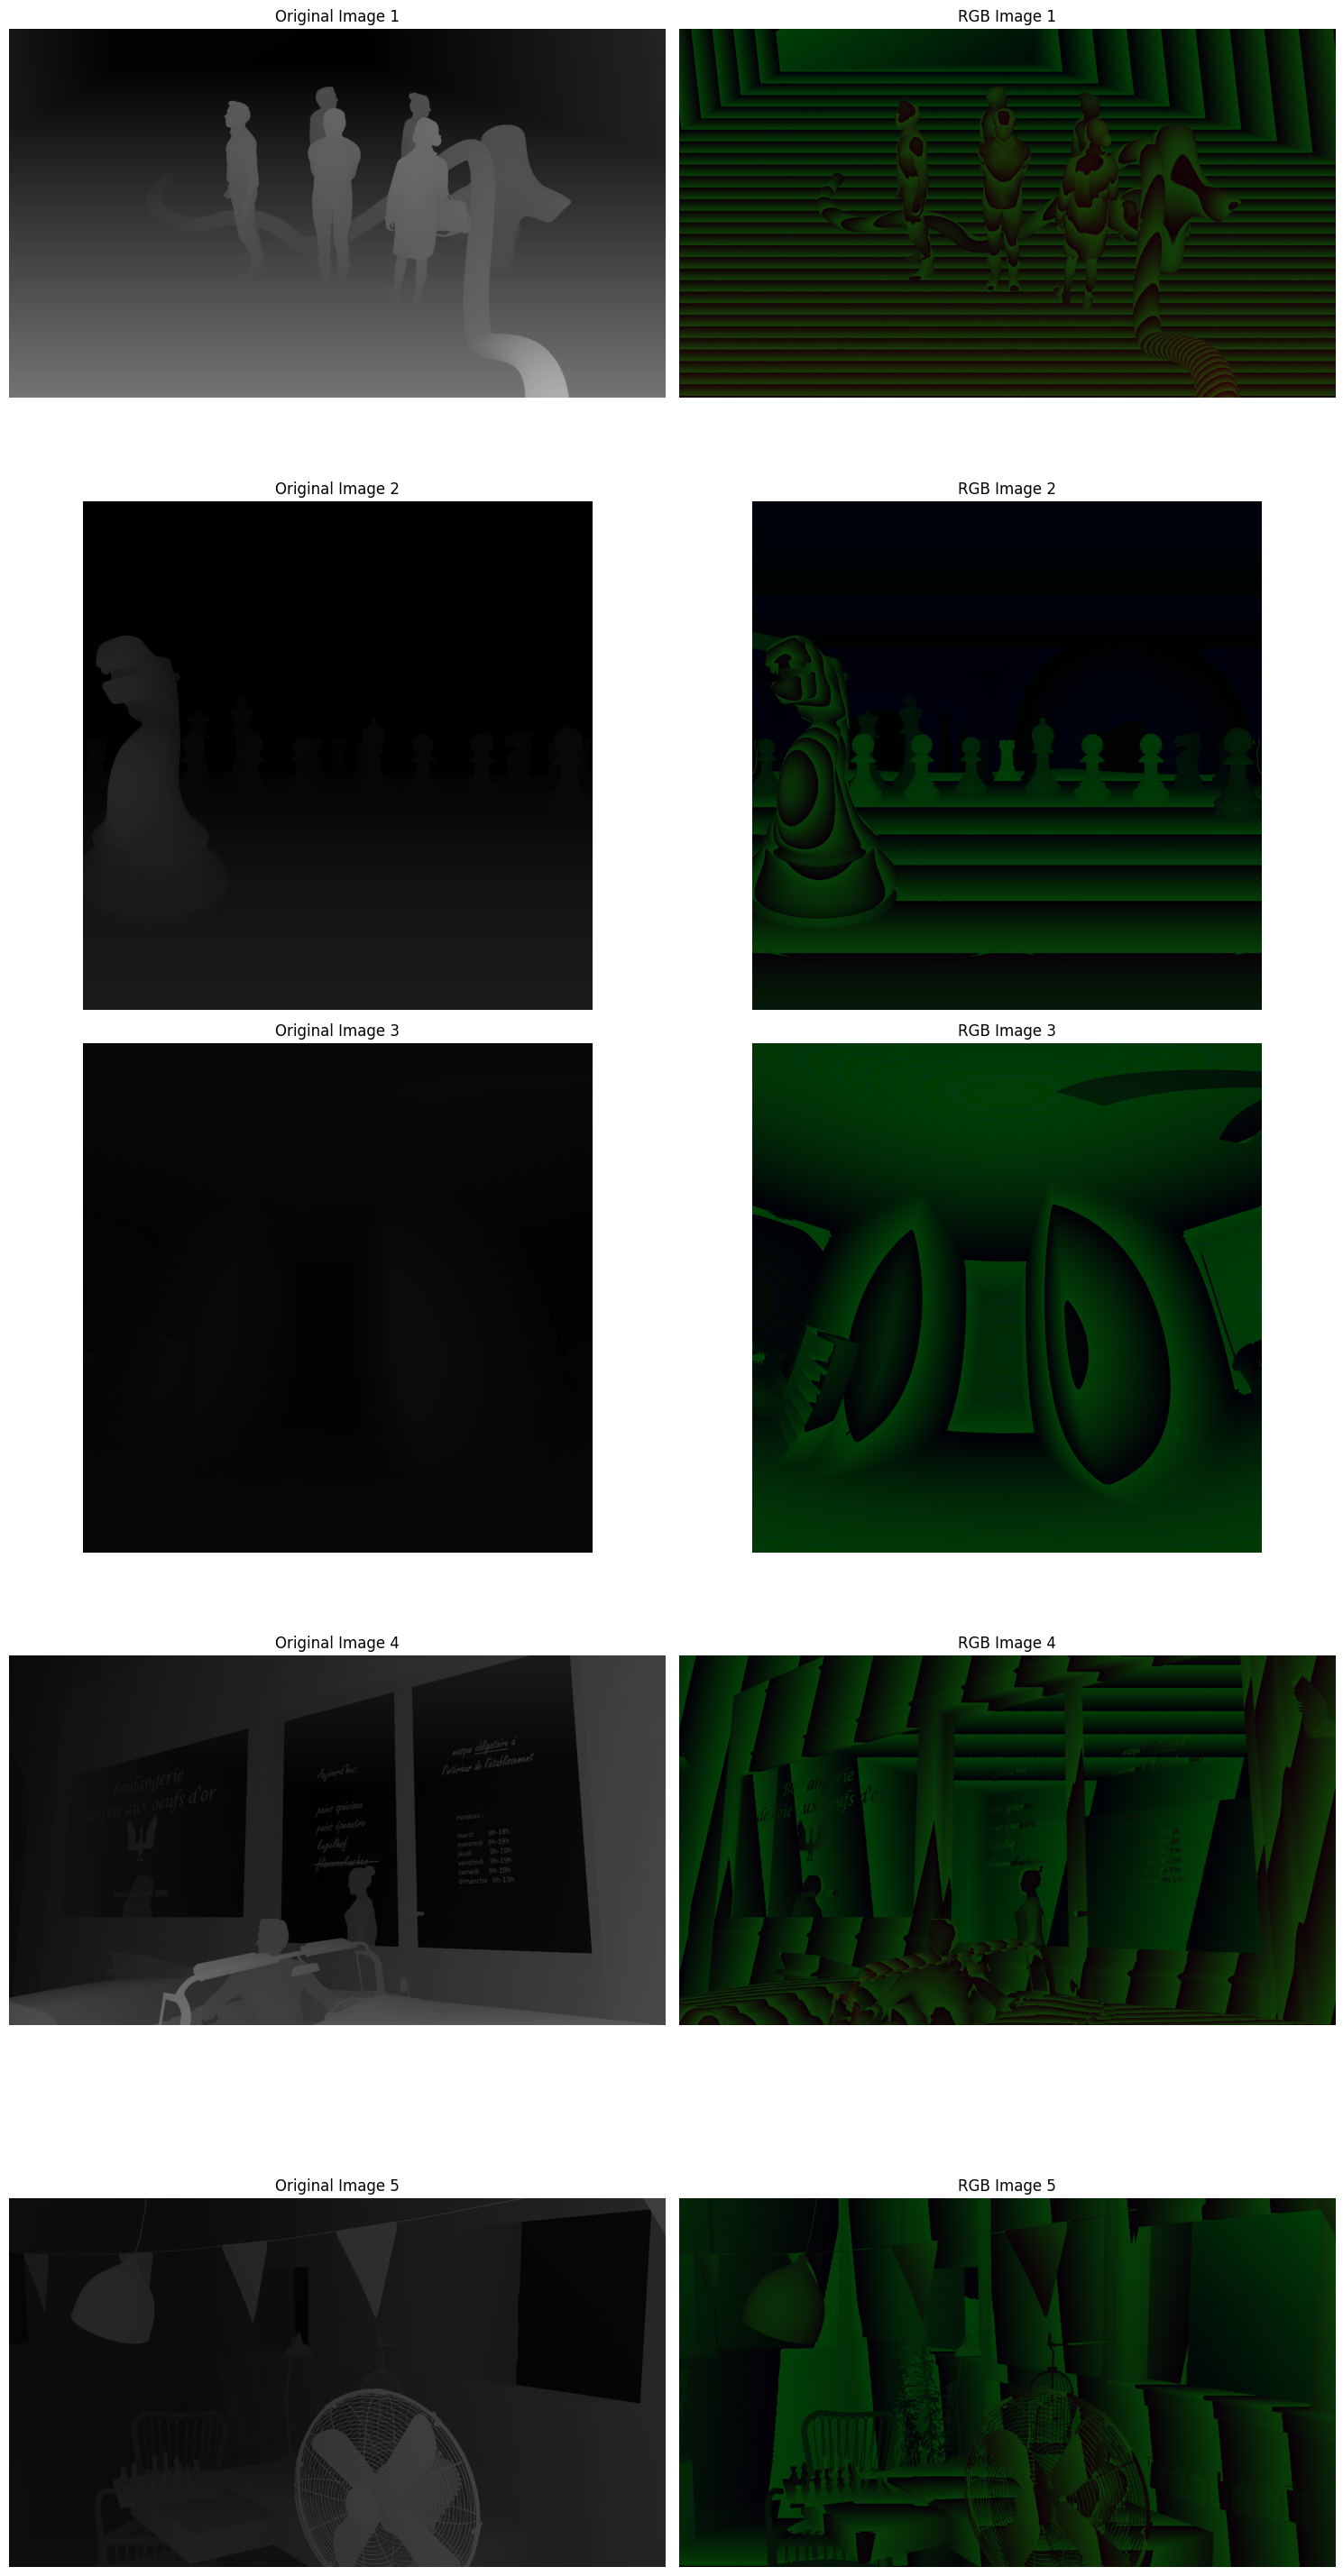

In [ ]:
#방법3

#16비트 이미지를 RGB로 변환하는 함수
def map_16bit_to_rgb(image_16bit):
    height, width = image_16bit.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)    #RGB 이미지 저장공간

#16비트를 6비트, 6비트, 4비트로 분리 후 매핑
    for i in range(height):
        for j in range(width):
            pixel_value = image_16bit[i, j]

            r_ch = (pixel_value >> 10) & 0x3F                   #상위 6비트
            g_ch = (pixel_value >> 4) & 0x3F                    #중간 6비트
            b_ch = pixel_value & 0x0F                           #하위 4비트

#RGB 각 채널에 매핑
            rgb_image[i, j, 0] = r_ch                           #R 채널
            rgb_image[i, j, 1] = g_ch                           #G 채널
            rgb_image[i, j, 2] = b_ch                           #B 채널

    return rgb_image

# 이미지 저장 리스트
results = []

for image_path in image_paths:

    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)        #원본 이미지 불러오기
    rgb_image = map_16bit_to_rgb(image)                         #RGB 이미지로 변환

    results.append((image,rgb_image))

# 시각화
plt.figure(figsize=(15, 30))

for idx, (original, rgb_image) in enumerate(results):

    plt.subplot(len(results), 2, idx * 2 + 1)
    plt.title(f'Original Image {idx + 1}')
    plt.imshow(original, cmap='gray', vmin=0, vmax=65535)
    plt.axis('off')

    plt.subplot(len(results), 2, idx * 2 + 2)
    plt.title(f'RGB Image {idx + 1}')
    plt.imshow(rgb_image, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

plt.tight_layout()
plt.show()
